# ME 3300 Lab 06 — Solution Notebook
**Strain Gauges, the Wheatstone Bridge, and Uncertainty in Young's Modulus**
*(two-week lab: Parts 1–4 in Week 1, Parts 5–6 in Week 2)*

Instructor solution. Acquisition cells (dwfpy) are guarded by
`ADS_CONNECTED = False` so the notebook runs end-to-end against the synthetic
TA dataset in `../Data/` (from `generate_synthetic_data.py`). Set the flag
True at the bench to exercise the hardware path.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from datetime import date

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Times', 'DejaVu Serif']
plt.rcParams['font.size'] = 10

ADS_CONNECTED = False  # True only at the bench with hardware attached
today = date.today().strftime('%b %d, %Y')

## Measured parameters (manual Parts 1–2)

Students substitute THEIR measured values. Synthetic 'measurements' below
are consistent with the TA dataset.

In [2]:
# Beam geometry (Part-1, measured)
L  = 0.3595      # m — gauge center to load point (tape measure, res 1 mm)
w  = 0.03805     # m — beam width (caliper, res 0.02 mm)
t  = 0.00640     # m — beam thickness (micrometer, res 0.01 mm)

# Local gravity (Part-1, sensorsone.com: lat 46.7324, elev 2579 ft)
g  = 9.8051      # m/s^2

# Bridge and amplifier (Part-2, measured)
GF   = 2.012     # gauge factor (apparatus datasheet)
R_G  = 101.7     # ohms — measured gain resistor
G    = 1 + 50500.0 / R_G          # AD622 gain (Lab 05, Eq. 3)
V_i  = 4.987     # V — excitation, measured at the bridge with the DMM

print(f"amplifier gain G = {G:.1f}")

amplifier gain G = 497.6


## Part-3 — bracketed load acquisition (hardware path)

Unload–load–unload for every mass: each loaded reading is bracketed by two
zero-load readings so the slow bridge drift can be averaged out.

In [3]:
if ADS_CONNECTED:
    import dwfpy as dwf
    import time

    masses = np.arange(0.4, 2.01, 0.2)     # kg
    v_unloaded = []                         # 10 readings (one per bracket)
    v_loaded   = []                         # 9 readings

    fs, duration = 50, 10.0
    n = int(fs * duration)

    with dwf.Device() as device:
        supplies = device.analog_io          # ±12 V for the AD622
        supplies['V+']['Voltage'].value = 12.0
        supplies['V+']['Enable'].value  = True
        supplies['V-']['Voltage'].value = -12.0
        supplies['V-']['Enable'].value  = True
        supplies.master_enable = True        # (bridge runs off the 5 V switch)
        time.sleep(0.5)

        scope = device.analog_input
        scope['ch1'].setup(range=5.0)

        def read_mean():
            """One 10-second averaged reading of the amplifier output."""
            scope.single(sample_rate=fs, buffer_size=n, configure=True, start=True)
            return scope['ch1'].get_data().mean()

        input("Beam UNLOADED and still. Hands off the bench, then Enter...")
        v_unloaded.append(read_mean())
        print(f"  unloaded: {v_unloaded[-1]:.5f} V")

        for m in masses:
            input(f"GENTLY hang {m:.1f} kg, let it settle, then Enter...")
            v_loaded.append(read_mean())
            print(f"  {m:.1f} kg loaded: {v_loaded[-1]:.5f} V")

            input("GENTLY remove the mass, then Enter...")
            v_unloaded.append(read_mean())
            print(f"  unloaded: {v_unloaded[-1]:.5f} V")

        supplies.master_enable = False

    v_unloaded = np.array(v_unloaded)
    v_loaded   = np.array(v_loaded)

    np.savetxt('../Data/StrainBridge_Loads.csv',
               np.column_stack([masses, v_loaded,
                                v_unloaded[:-1], v_unloaded[1:]]),
               header='mass_kg,v_loaded_V,v_unl_before_V,v_unl_after_V',
               delimiter=',')

## Part-4 — Week 1 analysis: drift-cancelled deltas, stress, strain, E

In [4]:
data = np.loadtxt('../Data/StrainBridge_Loads.csv', delimiter=',', comments='#')
masses   = data[:, 0]
v_load   = data[:, 1]
v_before = data[:, 2]
v_after  = data[:, 3]

# Two delta estimates per mass; their average cancels linear drift (Eq. 6)
dv1 = v_load - v_before
dv2 = v_load - v_after
dV  = (dv1 + dv2) / 2                  # amplified output change (V)

print("mass (kg) |  dv1 (mV) |  dv2 (mV) | dV_avg (mV)")
for m, a, b, c in zip(masses, dv1, dv2, dV):
    print(f"   {m:4.1f}   |  {a*1000:7.1f}  |  {b*1000:7.1f}  |  {c*1000:7.1f}")

# Strain from the half-bridge relation (Eq. 5), stress from bending (Eq. 3)
strain = 2 * dV / (V_i * G * GF)                 # m/m
stress = 6 * masses * g * L / (w * t**2)         # Pa

# Young's modulus = slope of stress vs strain (Lab 02 machinery)
coeffs = np.polyfit(strain, stress, 1)
E_fit  = coeffs[0]

N      = len(strain)
nu     = N - 2
resid  = stress - np.polyval(coeffs, strain)
norm_r = np.sqrt(np.sum(resid**2))
s_yx   = norm_r / np.sqrt(nu)
S_E    = s_yx / np.sqrt(np.sum((strain - strain.mean())**2))
CI_E   = stats.t.ppf(0.975, df=nu) * S_E

print(f"\nE = {E_fit/1e9:.2f} ± {CI_E/1e9:.2f} GPa (95% CI from the fit)")
print("published: steel 190–210 GPa, aluminum ~69 GPa, brass ~100 GPa")

mass (kg) |  dv1 (mV) |  dv2 (mV) | dV_avg (mV)
    0.4   |     67.7  |     66.3  |     67.0
    0.6   |    101.2  |    100.1  |    100.7
    0.8   |    134.5  |    133.3  |    133.9
    1.0   |    169.0  |    167.6  |    168.3
    1.2   |    203.7  |    199.1  |    201.4
    1.4   |    234.8  |    233.9  |    234.4
    1.6   |    269.1  |    266.0  |    267.5
    1.8   |    302.1  |    301.8  |    302.0
    2.0   |    336.0  |    333.2  |    334.6

E = 202.45 ± 0.79 GPa (95% CI from the fit)
published: steel 190–210 GPa, aluminum ~69 GPa, brass ~100 GPa


## Part-4 — the stress–strain deliverable figure

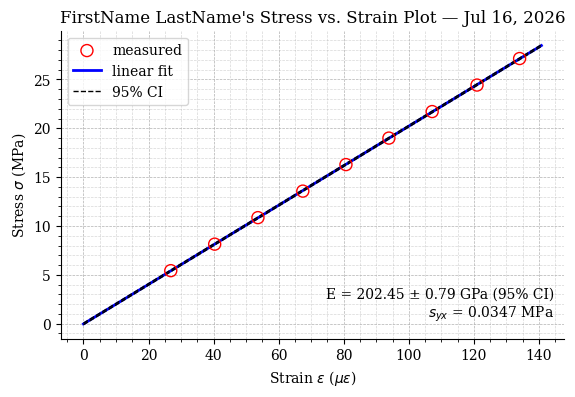

In [5]:
strain_line = np.linspace(0, strain.max() * 1.05, 100)

fig, ax = plt.subplots(figsize=(6.5, 4.0))
fig.patch.set_facecolor('white')

ax.scatter(strain * 1e6, stress / 1e6, s=75, facecolors='none',
           edgecolors='red', zorder=3, label='measured')
ax.plot(strain_line * 1e6, np.polyval(coeffs, strain_line) / 1e6,
        'b-', linewidth=2, label='linear fit')
ax.plot(strain_line * 1e6,
        (np.polyval(coeffs, strain_line) + stats.t.ppf(0.975, nu) * s_yx) / 1e6,
        'k--', linewidth=1, label='95% CI')
ax.plot(strain_line * 1e6,
        (np.polyval(coeffs, strain_line) - stats.t.ppf(0.975, nu) * s_yx) / 1e6,
        'k--', linewidth=1)

ax.set_xlabel(r'Strain $\varepsilon$ ($\mu\varepsilon$)')
ax.set_ylabel(r'Stress $\sigma$ (MPa)')
ax.set_title(f"FirstName LastName's Stress vs. Strain Plot — {today}")
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.5)
ax.minorticks_on()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper left')

ax.text(0.98, 0.05,
        f'E = {E_fit/1e9:.2f} ± {CI_E/1e9:.2f} GPa (95% CI)\n'
        f'$s_{{yx}}$ = {s_yx/1e6:.4f} MPa',
        transform=ax.transAxes, ha='right', va='bottom')

fig.savefig('../Figures/FirstName_LastName_Lab06_StressStrain.png',
            dpi=600, bbox_inches='tight')
fig.savefig('../Figures/FirstName_LastName_Lab06_StressStrain.pdf',
            dpi=600, bbox_inches='tight')
plt.show()

## Part-5 (Week 2) — uncertainty budget by the power rule

E = 3 m g L V_i G (GF) / (w t² ΔV) is a pure power law, so
u_E/E = sqrt( Σ (p_i · u_i/x_i)² ) with the exponents p_i below.

u_ΔV comes from the bracketing itself: the two delta estimates disagree by
roughly the drift, so half their typical disagreement is an honest,
empirical uncertainty.

In [6]:
u_dV = np.abs(dv1 - dv2).mean() / 2        # V — empirical, from bracketing
print(f"empirical u_dV = {u_dV*1000:.2f} mV")

def budget(m_eval, dV_eval):
    """Uncertainty budget for E at one mass. Returns (names, contribs, total)."""
    # (name, value, uncertainty, exponent in E)
    variables = [
        ('m',   m_eval,  0.01 * m_eval,      +1),   # 1% (weight set)
        ('g',   g,       1e-5 * g,           +1),   # 0.001%
        ('L',   L,       0.0005,             +1),   # tape: half of 1 mm
        ('V_i', V_i,     0.0005,             +1),   # DMM: half of 1 mV
        ('G',   G,       0.005 * G,          +1),   # R_G tolerance -> gain
        ('GF',  GF,      0.01 * GF,          +1),   # 1% (datasheet)
        ('w',   w,       0.00001,            -1),   # caliper: half of 0.02 mm
        ('t',   t,       0.000005,           -2),   # micrometer: half of 0.01 mm
        ('dV',  dV_eval, u_dV,               -1),   # empirical (above)
    ]
    names    = [v[0] for v in variables]
    rel      = np.array([p * u / x for _, x, u, p in variables])
    contribs = np.abs(rel) * E_fit           # per-variable, in Pa
    total    = np.sqrt(np.sum(contribs**2))
    return names, contribs, total


for m_eval in [0.4, 1.0, 1.4]:
    i = np.argmin(np.abs(masses - m_eval))
    names, contribs, total = budget(masses[i], dV[i])
    print(f"\n--- m = {masses[i]:.1f} kg ---")
    for name, cont in zip(names, contribs):
        print(f"  {name:>3}: ±{cont/1e9:6.3f} GPa")
    print(f"  TOTAL: ±{total/1e9:.3f} GPa  ({total/E_fit*100:.2f} %)")

print(f"\ncurve-fit 95% CI, for comparison: ±{CI_E/1e9:.3f} GPa")

empirical u_dV = 0.94 mV

--- m = 0.4 kg ---
    m: ± 2.025 GPa
    g: ± 0.002 GPa
    L: ± 0.282 GPa
  V_i: ± 0.020 GPa
    G: ± 1.012 GPa
   GF: ± 2.025 GPa
    w: ± 0.053 GPa
    t: ± 0.316 GPa
   dV: ± 2.851 GPa
  TOTAL: ±4.187 GPa  (2.07 %)

--- m = 1.0 kg ---
    m: ± 2.025 GPa
    g: ± 0.002 GPa
    L: ± 0.282 GPa
  V_i: ± 0.020 GPa
    G: ± 1.012 GPa
   GF: ± 2.025 GPa
    w: ± 0.053 GPa
    t: ± 0.316 GPa
   dV: ± 1.135 GPa
  TOTAL: ±3.270 GPa  (1.62 %)

--- m = 1.4 kg ---
    m: ± 2.025 GPa
    g: ± 0.002 GPa
    L: ± 0.282 GPa
  V_i: ± 0.020 GPa
    G: ± 1.012 GPa
   GF: ± 2.025 GPa
    w: ± 0.053 GPa
    t: ± 0.316 GPa
   dV: ± 0.815 GPa
  TOTAL: ±3.173 GPa  (1.57 %)

curve-fit 95% CI, for comparison: ±0.790 GPa


## Part-5 — the uncertainty-budget bar chart (Week 2 deliverable)

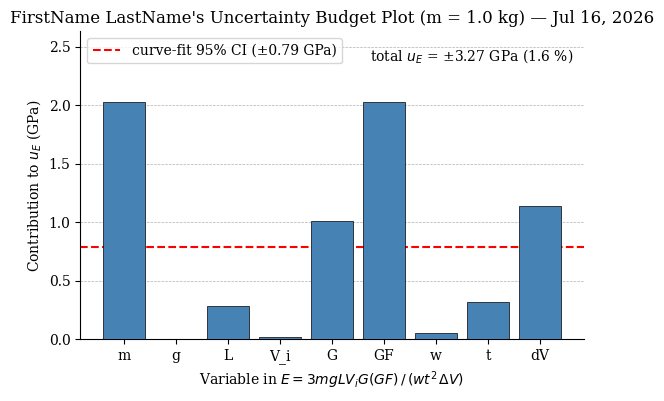

In [7]:
i = np.argmin(np.abs(masses - 1.0))            # budget at m = 1.0 kg
names, contribs, total = budget(masses[i], dV[i])

fig, ax = plt.subplots(figsize=(6.5, 4.0))
fig.patch.set_facecolor('white')

bars = ax.bar(names, contribs / 1e9, color='steelblue', edgecolor='black',
              linewidth=0.5, zorder=3)
ax.axhline(CI_E / 1e9, color='red', linestyle='--', linewidth=1.5,
           label=f'curve-fit 95% CI (±{CI_E/1e9:.2f} GPa)')

ax.set_xlabel(r'Variable in $E = 3mgLV_iG(GF)\,/\,(wt^2\,\Delta V)$')
ax.set_ylabel('Contribution to $u_E$ (GPa)')
ax.set_ylim(0, contribs.max() / 1e9 * 1.3)
ax.set_title(f"FirstName LastName's Uncertainty Budget Plot (m = 1.0 kg) — {today}")
ax.grid(which='major', axis='y', linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()

ax.text(0.98, 0.95, f'total $u_E$ = ±{total/1e9:.2f} GPa ({total/E_fit*100:.1f} %)',
        transform=ax.transAxes, ha='right', va='top')

fig.savefig('../Figures/FirstName_LastName_Lab06_UncertaintyBudget.png',
            dpi=600, bbox_inches='tight')
fig.savefig('../Figures/FirstName_LastName_Lab06_UncertaintyBudget.pdf',
            dpi=600, bbox_inches='tight')
plt.show()

## Grading / checking notes (TA)

**Week 1 (Parts 1–4).**
- Expected E: 195–215 GPa for the steel beam (synthetic truth: 203). Values
  near 100 or 400 GPa usually mean a factor-of-2 slip in the half-bridge
  equation (missing the 2, or dividing by it twice) or G computed from the
  nominal 102 Ω instead of measured R_G — check their Eq. 5 line first.
- dV table: dv1 and dv2 should disagree by ~1–2 mV (the drift). If they
  disagree by 20+ mV someone bumped the wires — the manual's don't-touch
  warning exists for this. If dv1 = dv2 exactly, they reused one unloaded
  column twice.
- Zero-load output anywhere from ~0.5–3 V is normal (bridge imbalance ×
  500); it subtracts out. A zero-load output pinned at ±11 V means the
  bridge is badly unbalanced (wrong resistor) or an input wire is open.
- Stress–strain intercept should be within ± a few s_yx of zero — the
  deltas force it. A large intercept means they used raw voltages, not
  deltas.

**Week 2 (Parts 5–6).**
- Dominant budget terms should be GF (1%), m (1%), and dV (drift-limited,
  biggest at 0.4 kg); geometry terms are tiny. Students whose t-term
  dominates likely used the exponent +2 instead of −2 magnitude or wrong
  units (mm vs m).
- Propagated total (~1.5–2.5% of E) should EXCEED the curve-fit CI: the fit
  only sees point-to-point scatter, while GF/G/V_i push all points together
  (systematic). Students who get this inversion right in Q-answers are
  thinking correctly.
- Hand-calc table (one mass) must match their Python budget to rounding.
  Common slip: forgetting to halve resolution for u, or 1% of the wrong
  quantity.